In [10]:
import pandas as pd
import json

In [11]:
csv_path='INvideos.csv'
json_path='IN_category_id (1).json'
with open(json_path, 'r', encoding='utf-8') as f:
 category_data = json.load(f)
    
category_dict = {int(item['id']): item['snippet']['title'] for item in category_data['items']}

In [13]:
try:
        df = pd.read_csv(csv_path, encoding='utf-8')
except UnicodeDecodeError:
        df = pd.read_csv(csv_path, encoding='latin-1')

In [14]:
df['category'] = df['category_id'].map(category_dict)

In [28]:
df['trending_date'] = pd.to_datetime(df['trending_date'], errors='coerce')
df['publish_time'] = pd.to_datetime(df['publish_time'], errors='coerce')
df['trending_date'] = df['trending_date'].dt.tz_localize(None)
df['publish_time'] = df['publish_time'].dt.tz_localize(None)
df = df.dropna(subset=['video_id', 'trending_date', 'publish_time'])
df['region'] = 'IN'
df['days_to_trend'] = (df['trending_date'] - df['publish_time']).dt.days
df


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,category,region,days_to_trend
3256,6ZfuNTqbHE8,2012-01-17,Marvel Studios' Avengers: Infinity War Officia...,Marvel Entertainment,24,2017-11-29 13:26:24,"marvel|""comics""|""comic books""|""nerdy""|""geeky""|...",56367282,2157733,34077,303178,https://i.ytimg.com/vi/6ZfuNTqbHE8/default.jpg,False,False,False,There was an idea… Avengers: Infinity War. In ...,Entertainment,IN,-2144
3257,hYM_iZII4U4,2012-01-17,Thaanaa Serndha Koottam Official Tamil Teaser ...,Sony Music India,10,2017-11-30 13:30:03,"Thaanaa Serndha Koottam - Naana Thaana Lyric|""...",3679229,294624,58475,18872,https://i.ytimg.com/vi/hYM_iZII4U4/default.jpg,False,False,False,"'Veratti veratti velukka thonuthu,\nAthigaara ...",Music,IN,-2145
3258,yKkheNpuOKU,2012-01-17,Salman Khan और Katrina भी रोये जब अमिताभ बच्चन...,Prime Minister Narender Modi,24,2017-11-29 03:10:22,"amitabh bachchan|""iffi""|""goa""|""akshay kumar""|""...",2243552,13738,1834,1291,https://i.ytimg.com/vi/yKkheNpuOKU/default.jpg,False,False,False,NaN,Entertainment,IN,-2144
3259,Ta3Yruzx_lA,2012-01-17,Oru Nalla Naal Paathu Solren Teaser | Vijay Se...,Think Music India,1,2017-11-29 12:20:45,"Oru Nalla Naal Paathu Solren Teaser|""Oru Nalla...",1595682,67254,1342,1886,https://i.ytimg.com/vi/Ta3Yruzx_lA/default.jpg,False,False,False,#OruNallaNaalPaathuSolrenTeaser | #OruNallaNaa...,Film & Animation,IN,-2144
3260,Ut-JRKyMjEI,2012-01-17,Audition Gone Wrong Ft. Ashish Chanchlani | Mo...,MostlySane,23,2017-11-30 05:30:00,"prajakta koli|""mostly sane""|""mostlysane""|""late...",486946,25582,1187,1623,https://i.ytimg.com/vi/Ut-JRKyMjEI/default.jpg,False,False,False,"Hey dumdums this was such a fun collaboration,...",Comedy,IN,-2145
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37005,a4oVaZ2O8iI,2006-12-18,Guru Randhawa - Made in India - Behind the scenes,Guru Randhawa,10,2018-06-10 11:03:25,"guru randhawa|""live show""|""guru randhawa live""...",646772,13819,557,1211,https://i.ytimg.com/vi/a4oVaZ2O8iI/default.jpg,False,False,False,Guru Randhawa: Social AccountsWebsite : http:/...,Music,IN,-4193
37006,9fyeNrb7wag,2006-12-18,Jaani Tera Naa | Shirley Setia | Vivek Dadhich...,Shirley Setia,10,2018-06-07 08:19:46,"shirley setia|""shirley setia covers""|""shirley ...",2065269,59553,4694,3249,https://i.ytimg.com/vi/9fyeNrb7wag/default.jpg,False,False,False,Click to Subscribe:- http://bit.ly/ShirleySeti...,Music,IN,-4190
37007,G_ga7EGEGWo,2006-12-18,Seetha | Flowers | Ep# 362,Flowers TV,24,2018-06-11 11:30:00,"flowers serials|""actress""|""malayalam serials""|...",258622,1564,305,1219,https://i.ytimg.com/vi/G_ga7EGEGWo/default.jpg,False,False,False,"Flowers - A R Rahman Show,Book your Tickets He...",Entertainment,IN,-4194
37008,QEC4HkHgUb4,2006-12-18,Uppum Mulakum│Flowers│EP# 622,Flowers Comedy,24,2018-06-09 14:00:06,"flowers tv|""uppum mulakum""|""uppum""|""biju sopan...",1324375,9297,1038,1932,https://i.ytimg.com/vi/QEC4HkHgUb4/default.jpg,False,False,False,"Flowers - A R Rahman Show,Book your Tickets He...",Entertainment,IN,-4192


In [29]:
print("Data Cleaning Framework Ready.")

Data Cleaning Framework Ready.


In [33]:
from textblob import TextBlob
import pandas as pd

def get_sentiment_polarity(text):
    if pd.isna(text) or text.lower() == '[none]':
        return 0.0
    return TextBlob(str(text)).sentiment.polarity

def classify_sentiment(score):
    if score > 0.05:
        return 'Positive'
    elif score < -0.05:
        return 'Negative'
    else:
        return 'Neutral'
print("NLP Sentiment Pipeline Ready.")

NLP Sentiment Pipeline Ready.


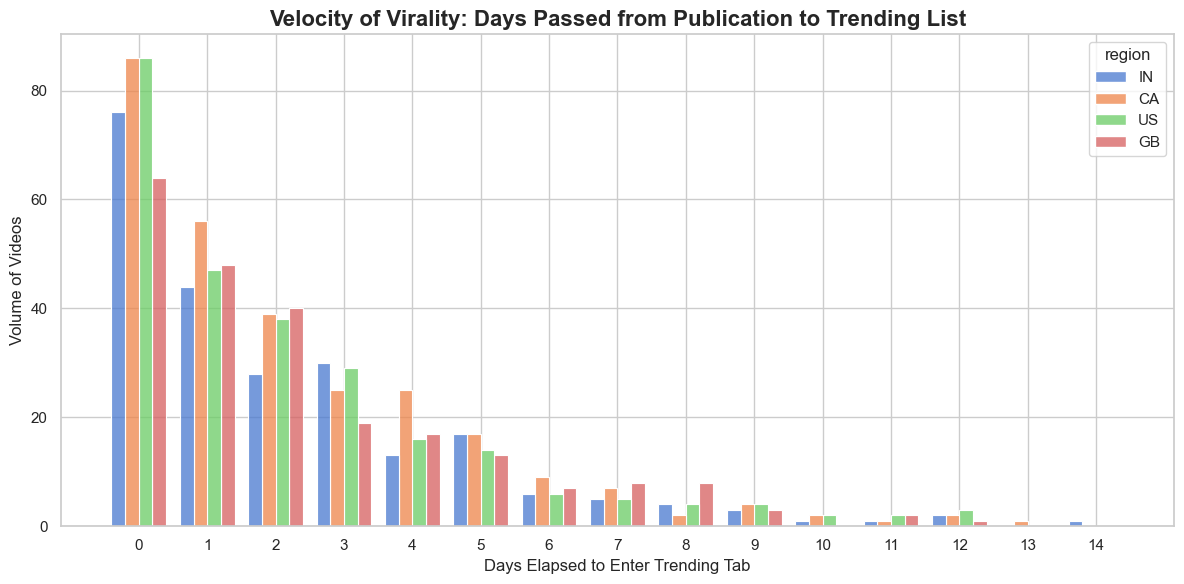

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
np.random.seed(42)
mock_data = {
    'region': np.random.choice(['US', 'GB', 'IN', 'CA'], 1000),
    'days_to_trend': np.random.geometric(p=0.3, size=1000) - 1,
    'title_sentiment_score': np.random.uniform(-1, 1, 1000),
    'views': np.random.exponential(scale=1000000, size=1000)
}
df = pd.DataFrame(mock_data)
df = df[df['days_to_trend'] <= 14]

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")


sns.histplot(
    data=df, 
    x='days_to_trend', 
    hue='region', 
    multiple='dodge', 
    shrink=0.8, 
    discrete=True,
    palette='muted'
)

plt.title('Velocity of Virality: Days Passed from Publication to Trending List', fontsize=16, fontweight='bold')
plt.xlabel('Days Elapsed to Enter Trending Tab', fontsize=12)
plt.ylabel('Volume of Videos', fontsize=12)
plt.xticks(range(0, 15))
plt.tight_layout()
plt.show()